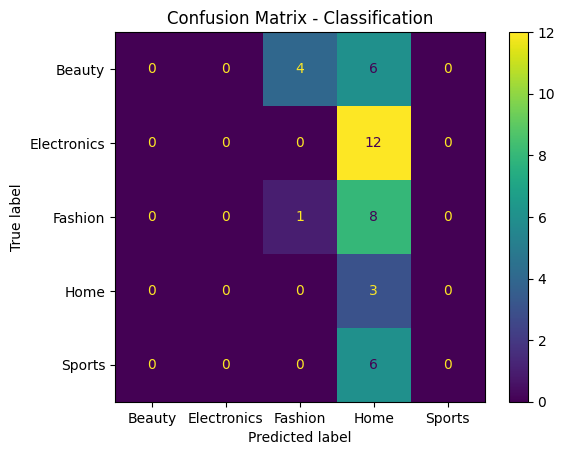

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_excel(r"C:\Users\sudhi\Desktop\Reasearch_dataset\ecommerce_data.xlsx")

# Clean
data.columns = data.columns.str.strip().str.lower()
data.rename(columns={'standerd_price': 'standard_price'}, inplace=True)

# Convert
data['product_price'] = pd.to_numeric(data['product_price'], errors='coerce')
data['standard_price'] = pd.to_numeric(data['standard_price'], errors='coerce')

data = data.dropna(subset=['product_price', 'standard_price', 'category'])

# Features
X = data[['product_price', 'standard_price']]
y = data['category']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# 🔥 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

plt.title("Confusion Matrix - Classification")
plt.show()